# 🍽️ Restaurant Database — Deep Data Analysis
**Data Sources:** `menu_items.csv`, `order_details.csv`, `restaurant_db_data_dictionary.csv`

---
## Table of Contents
1. Setup & Data Loading
2. Data Quality & Overview
3. Menu Analysis
4. Order Volume & Trends
5. Revenue Analysis
6. Time-Based Analysis
7. Category Performance
8. Item-Level Deep Dive
9. Order Complexity Analysis
10. Popularity vs. Revenue Matrix
11. Combo / Co-occurrence Analysis
12. Business Insights Summary


## 1. Setup & Data Loading

In [1]:
# ── Install / import libraries ──────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import combinations
from collections import Counter

# ── Plot aesthetics ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

CATEGORY_COLORS = {
    'American': '#4C72B0',
    'Asian':    '#DD8452',
    'Mexican':  '#55A868',
    'Italian':  '#C44E52',
}

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load raw data ────────────────────────────────────────────────────────────
menu     = pd.read_csv('menu_items.csv')
orders   = pd.read_csv('order_details.csv')
data_dict = pd.read_csv('restaurant_db_data_dictionary.csv')

# ── Parse datetime fields ────────────────────────────────────────────────────
orders['order_date'] = pd.to_datetime(orders['order_date'], format='%m/%d/%y')
orders['order_time'] = pd.to_datetime(orders['order_time'], format='%I:%M:%S %p').dt.time
orders['order_datetime'] = pd.to_datetime(
    orders['order_date'].astype(str) + ' ' + orders['order_time'].astype(str)
)

# ── Derived date features ────────────────────────────────────────────────────
orders['month']        = orders['order_date'].dt.month
orders['month_name']   = orders['order_date'].dt.strftime('%b')
orders['day_of_week']  = orders['order_date'].dt.day_name()
orders['week_number']  = orders['order_date'].dt.isocalendar().week.astype(int)
orders['hour']         = orders['order_datetime'].dt.hour
orders['quarter']      = orders['order_date'].dt.quarter

# ── Merge orders with menu ───────────────────────────────────────────────────
df = orders.merge(menu, left_on='item_id', right_on='menu_item_id', how='left')

print(f'order_details rows : {len(orders):,}')
print(f'menu_items rows    : {len(menu):,}')
print(f'Merged df rows     : {len(df):,}')
print(f'Unique orders      : {df["order_id"].nunique():,}')
print(f'Date range         : {orders["order_date"].min().date()} → {orders["order_date"].max().date()}')

order_details rows : 12,234
menu_items rows    : 32
Merged df rows     : 12,234
Unique orders      : 5,370
Date range         : 2023-01-01 → 2023-03-31


## 2. Data Quality & Overview

In [3]:
# ── Data dictionary ──────────────────────────────────────────────────────────
print('=== Data Dictionary ===')
print(data_dict.to_string(index=False))

=== Data Dictionary ===
        Table            Field                                      Description
   menu_items     menu_item_id                         Unique ID of a menu item
   menu_items        item_name                              Name of a menu item
   menu_items         category     Category or type of cuisine of the menu item
   menu_items            price            Price of the menu item (US Dollars $)
order_details order_details_id                 Unique ID of an item in an order
order_details         order_id                                   ID of an order
order_details       order_date              Date an order was put in (MM/DD/YY)
order_details       order_time        Time an order was put in (HH:MM:SS AM/PM)
order_details          item_id Matches the menu_item_id in the menu_items table


In [4]:
# ── Shape & dtypes ───────────────────────────────────────────────────────────
print('--- menu_items ---')
print(menu.info())
print('\n--- order_details ---')
print(orders.info())

--- menu_items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   menu_item_id  32 non-null     int64  
 1   item_name     32 non-null     object 
 2   category      32 non-null     object 
 3   price         32 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
None

--- order_details ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12234 non-null  int64         
 1   order_id          12234 non-null  int64         
 2   order_date        12234 non-null  datetime64[ns]
 3   order_time        12234 non-null  object        
 4   item_id           12097 non-null  float64       
 5   order_datetime    12234 non-null  datet

In [5]:
# ── Missing values ───────────────────────────────────────────────────────────
print('Missing values in merged df:')
missing = df.isnull().sum()
print(missing[missing > 0])

# flag unmatched orders (item_id not in menu)
unmatched = df[df['item_name'].isnull()]
print(f'\nOrders with no menu match: {len(unmatched):,}')
if len(unmatched) > 0:
    print(unmatched['item_id'].value_counts())

Missing values in merged df:
item_id         137
menu_item_id    137
item_name       137
category        137
price           137
dtype: int64

Orders with no menu match: 137
Series([], Name: count, dtype: int64)


In [6]:
# ── Basic descriptive stats ──────────────────────────────────────────────────
print('Menu price statistics:')
print(menu['price'].describe().round(2))

print('\nOrder detail stats:')
print(orders[['order_id']].describe())

Menu price statistics:
count    32.00
mean     13.29
std       3.86
min       5.00
25%      10.50
50%      13.95
75%      15.75
max      19.95
Name: price, dtype: float64

Order detail stats:
           order_id
count  12234.000000
mean    2691.927415
std     1546.026261
min        1.000000
25%     1351.250000
50%     2710.000000
75%     4020.000000
max     5370.000000


## 3. Menu Analysis

In [7]:
print(menu.to_string(index=False))

 menu_item_id             item_name category  price
          101             Hamburger American  12.95
          102          Cheeseburger American  13.95
          103               Hot Dog American   9.00
          104         Veggie Burger American  10.50
          105          Mac & Cheese American   7.00
          106          French Fries American   7.00
          107        Orange Chicken    Asian  16.50
          108         Tofu Pad Thai    Asian  14.50
          109      Korean Beef Bowl    Asian  17.95
          110            Pork Ramen    Asian  17.95
          111       California Roll    Asian  11.95
          112           Salmon Roll    Asian  14.95
          113               Edamame    Asian   5.00
          114           Potstickers    Asian   9.00
          115         Chicken Tacos  Mexican  11.95
          116           Steak Tacos  Mexican  13.95
          117       Chicken Burrito  Mexican  12.95
          118         Steak Burrito  Mexican  14.95
          11

In [8]:
# ── Items per category & price stats ────────────────────────────────────────
cat_stats = menu.groupby('category').agg(
    num_items=('item_name', 'count'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median')
).round(2)
print(cat_stats)

          num_items  min_price  max_price  avg_price  median_price
category                                                          
American          6        7.0      13.95      10.07          9.75
Asian             8        5.0      17.95      13.48         14.72
Italian           9       14.5      19.95      16.75         16.95
Mexican           9        7.0      14.95      11.80         11.95


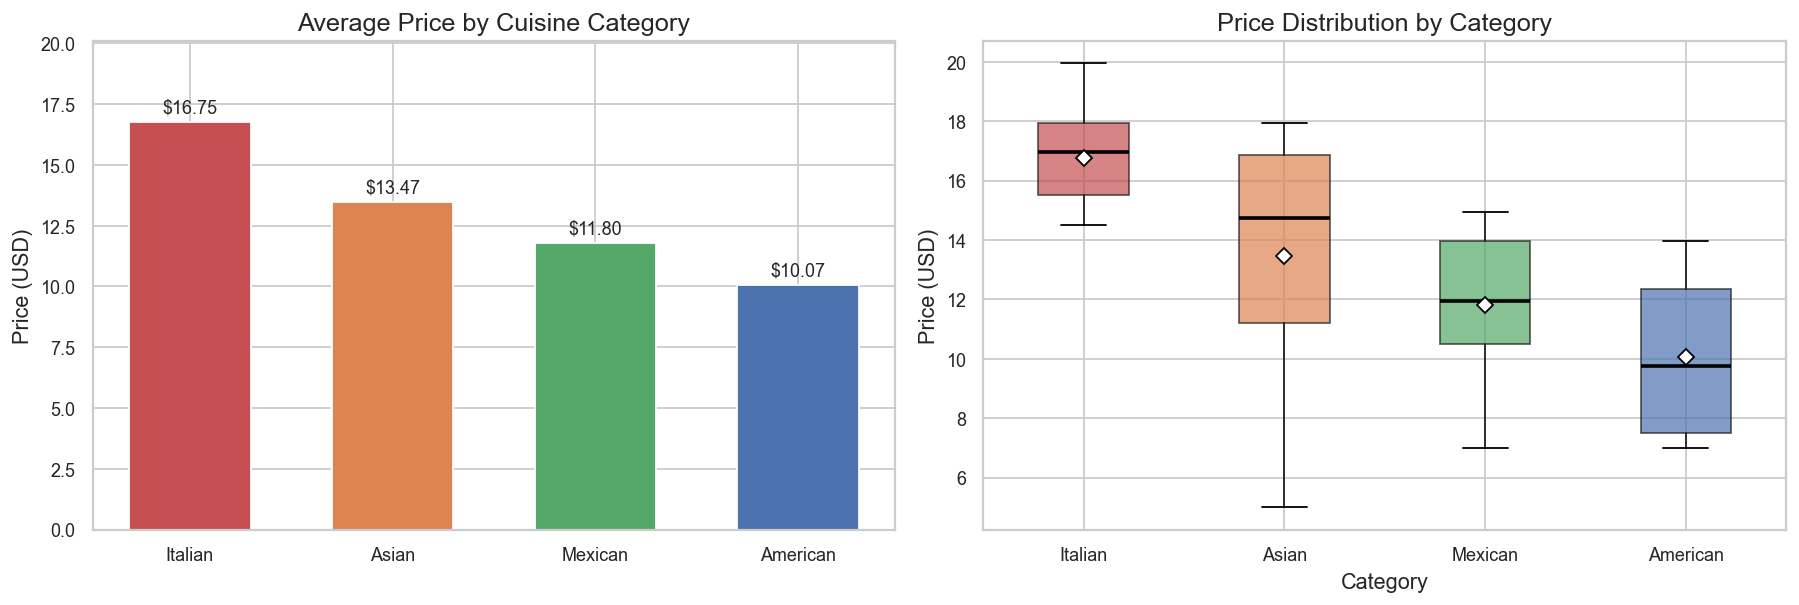

In [9]:
# ── Menu price distribution by category ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: avg price per category
avg_prices = menu.groupby('category')['price'].mean().sort_values(ascending=False)
bars = axes[0].bar(avg_prices.index,
                    avg_prices.values,
                    color=[CATEGORY_COLORS[c] for c in avg_prices.index],
                    edgecolor='white', width=0.6)
axes[0].bar_label(bars, fmt='$%.2f', padding=3, fontsize=10)
axes[0].set_title('Average Price by Cuisine Category')
axes[0].set_ylabel('Price (USD)')
axes[0].set_ylim(0, avg_prices.max() * 1.2)

# Box: price spread per category
cat_order = menu.groupby('category')['price'].median().sort_values(ascending=False).index
menu_plot = menu.copy()
menu_plot['category'] = pd.Categorical(menu_plot['category'], categories=cat_order, ordered=True)
bp = menu_plot.boxplot(column='price', by='category', ax=axes[1],
                        patch_artist=True, showmeans=True,
                        medianprops=dict(color='black', linewidth=2),
                        meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, cat in zip(axes[1].patches, cat_order):
    patch.set_facecolor(CATEGORY_COLORS[cat])
    patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Price (USD)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [10]:
# ── Cheapest & most expensive items ─────────────────────────────────────────
print('Top 5 most expensive items:')
print(menu.nlargest(5, 'price')[['item_name', 'category', 'price']].to_string(index=False))

print('\nTop 5 cheapest items:')
print(menu.nsmallest(5, 'price')[['item_name', 'category', 'price']].to_string(index=False))

Top 5 most expensive items:
            item_name category  price
        Shrimp Scampi  Italian  19.95
     Korean Beef Bowl    Asian  17.95
           Pork Ramen    Asian  17.95
Spaghetti & Meatballs  Italian  17.95
         Meat Lasagna  Italian  17.95

Top 5 cheapest items:
    item_name category  price
      Edamame    Asian    5.0
 Mac & Cheese American    7.0
 French Fries American    7.0
Chips & Salsa  Mexican    7.0
      Hot Dog American    9.0


## 4. Order Volume & Trends

In [11]:
# ── High-level order KPIs ────────────────────────────────────────────────────
total_orders   = df['order_id'].nunique()
total_items    = len(df)
total_revenue  = df['price'].sum()
avg_order_val  = df.groupby('order_id')['price'].sum().mean()
avg_items_per  = df.groupby('order_id')['price'].count().mean()
days           = (df['order_date'].max() - df['order_date'].min()).days + 1

print(f'Total unique orders   : {total_orders:,}')
print(f'Total items sold      : {total_items:,}')
print(f'Total revenue         : ${total_revenue:,.2f}')
print(f'Avg order value       : ${avg_order_val:.2f}')
print(f'Avg items per order   : {avg_items_per:.2f}')
print(f'Operating days        : {days}')
print(f'Avg orders / day      : {total_orders/days:.1f}')
print(f'Avg revenue / day     : ${total_revenue/days:,.2f}')

Total unique orders   : 5,370
Total items sold      : 12,234
Total revenue         : $159,217.90
Avg order value       : $29.65
Avg items per order   : 2.25
Operating days        : 90
Avg orders / day      : 59.7
Avg revenue / day     : $1,769.09


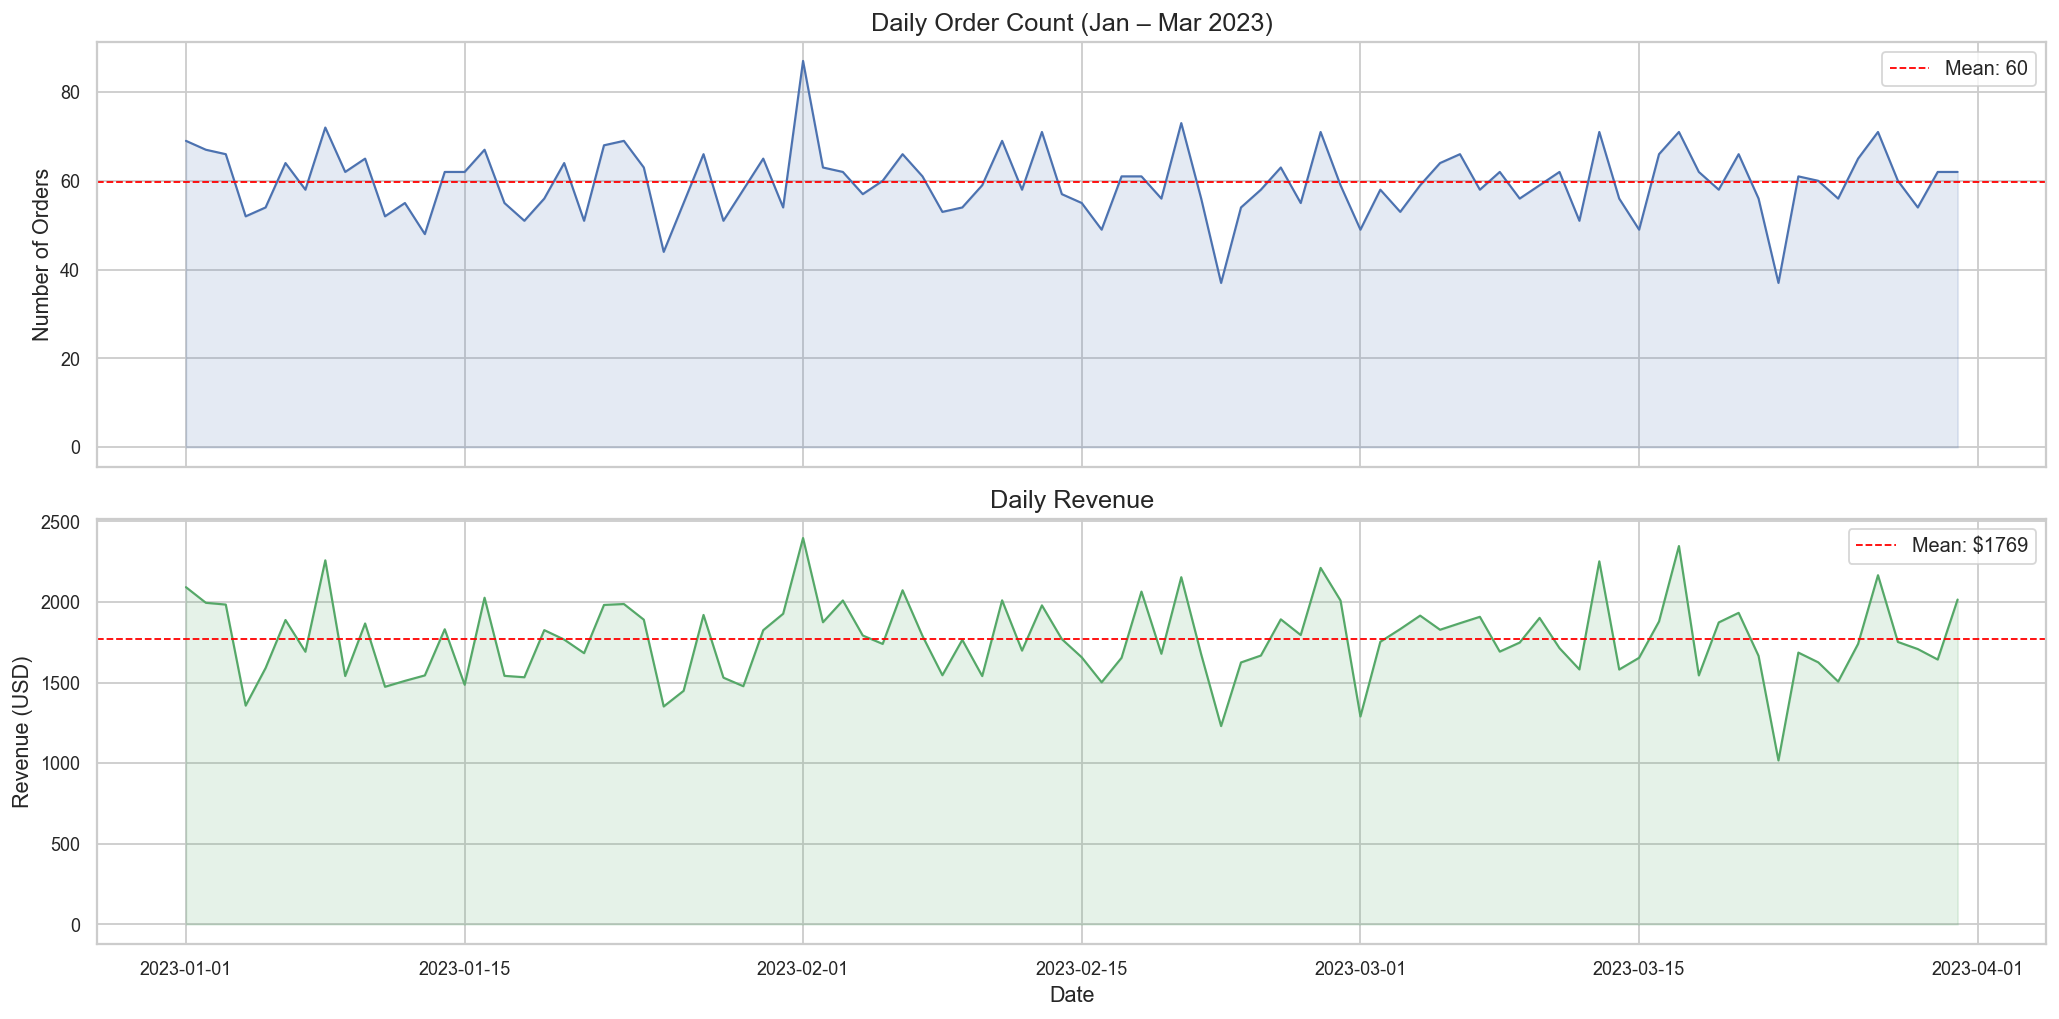

In [12]:
# ── Daily order count over time ──────────────────────────────────────────────
daily_orders = df.groupby('order_date')['order_id'].nunique()
daily_revenue = df.groupby('order_date')['price'].sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(daily_orders.index, daily_orders.values, color='#4C72B0', linewidth=1.2)
axes[0].fill_between(daily_orders.index, daily_orders.values, alpha=0.15, color='#4C72B0')
axes[0].axhline(daily_orders.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {daily_orders.mean():.0f}')
axes[0].set_title('Daily Order Count (Jan – Mar 2023)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

axes[1].plot(daily_revenue.index, daily_revenue.values, color='#55A868', linewidth=1.2)
axes[1].fill_between(daily_revenue.index, daily_revenue.values, alpha=0.15, color='#55A868')
axes[1].axhline(daily_revenue.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: ${daily_revenue.mean():.0f}')
axes[1].set_title('Daily Revenue')
axes[1].set_ylabel('Revenue (USD)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# ── Monthly aggregates ───────────────────────────────────────────────────────
month_map = {1:'Jan', 2:'Feb', 3:'Mar'}
monthly = df.groupby('month').agg(
    orders=('order_id', 'nunique'),
    items_sold=('item_id', 'count'),
    revenue=('price', 'sum')
).round(2)
monthly.index = monthly.index.map(month_map)
monthly['avg_order_value'] = (monthly['revenue'] / monthly['orders']).round(2)
print(monthly)

       orders  items_sold   revenue  avg_order_value
month                                               
Jan      1845        4104  53816.95            29.17
Feb      1685        3851  50790.35            30.14
Mar      1840        4142  54610.60            29.68


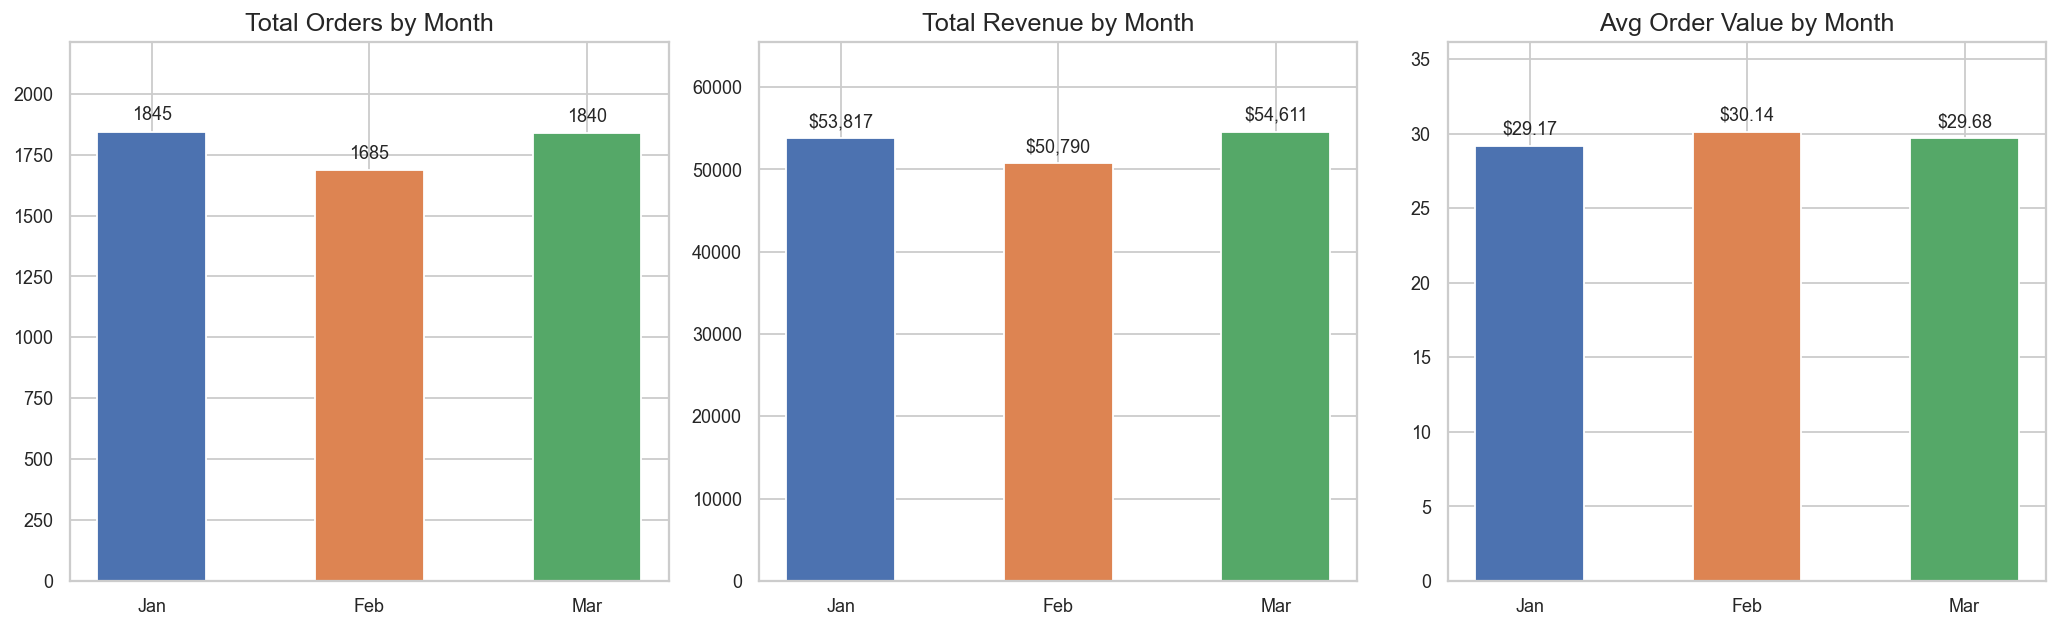

In [14]:
# ── Monthly bar charts ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
months = monthly.index.tolist()
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, title, fmt in zip(
    axes,
    ['orders', 'revenue', 'avg_order_value'],
    ['Total Orders by Month', 'Total Revenue by Month', 'Avg Order Value by Month'],
    ['{:.0f}', '${:,.0f}', '${:.2f}']
):
    bars = ax.bar(months, monthly[col], color=colors, edgecolor='white', width=0.5)
    ax.bar_label(bars, labels=[fmt.format(v) for v in monthly[col]], padding=4, fontsize=10)
    ax.set_title(title)
    ax.set_ylim(0, monthly[col].max() * 1.2)

plt.tight_layout()
plt.show()

## 5. Revenue Analysis

In [15]:
# ── Revenue per category ─────────────────────────────────────────────────────
cat_revenue = df.groupby('category').agg(
    total_revenue=('price', 'sum'),
    items_sold=('item_id', 'count'),
    avg_price=('price', 'mean')
).sort_values('total_revenue', ascending=False).round(2)
cat_revenue['revenue_share_%'] = (cat_revenue['total_revenue'] / cat_revenue['total_revenue'].sum() * 100).round(1)
print(cat_revenue)

          total_revenue  items_sold  avg_price  revenue_share_%
category                                                       
Italian        49462.70        2948      16.78             31.1
Asian          46720.65        3470      13.46             29.3
Mexican        34796.80        2945      11.82             21.9
American       28237.75        2734      10.33             17.7


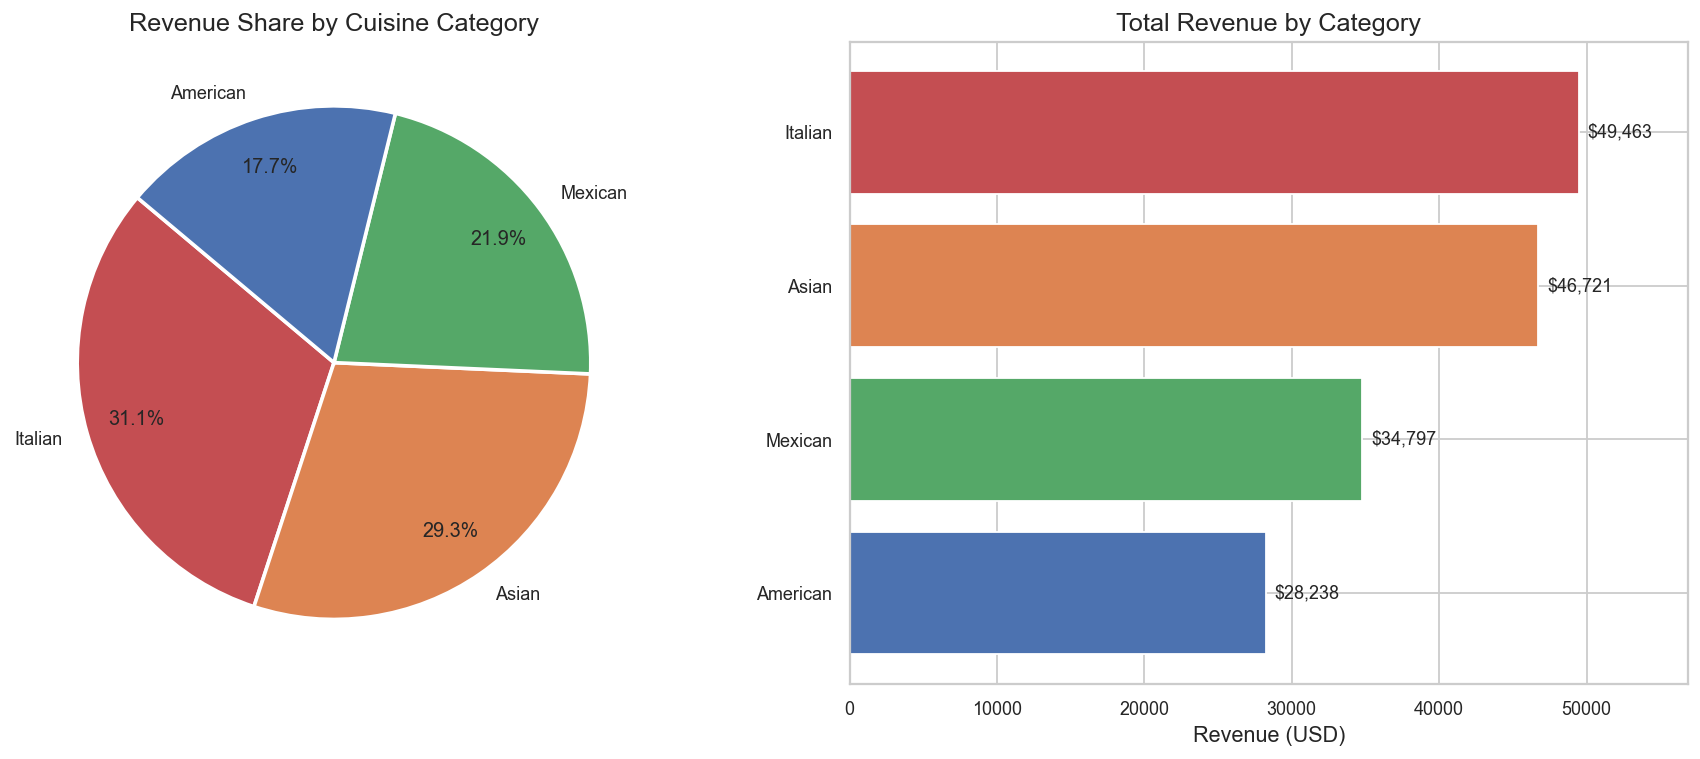

In [16]:
# ── Revenue share pie + bar ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = axes[0].pie(
    cat_revenue['total_revenue'],
    labels=cat_revenue.index,
    autopct='%1.1f%%',
    colors=[CATEGORY_COLORS[c] for c in cat_revenue.index],
    startangle=140, pctdistance=0.8,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
axes[0].set_title('Revenue Share by Cuisine Category')

h_bars = axes[1].barh(
    cat_revenue.index[::-1],
    cat_revenue['total_revenue'][::-1],
    color=[CATEGORY_COLORS[c] for c in cat_revenue.index[::-1]],
    edgecolor='white'
)
axes[1].bar_label(h_bars, labels=[f'${v:,.0f}' for v in cat_revenue['total_revenue'][::-1]], padding=5, fontsize=10)
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Revenue (USD)')
axes[1].set_xlim(0, cat_revenue['total_revenue'].max() * 1.15)

plt.tight_layout()
plt.show()

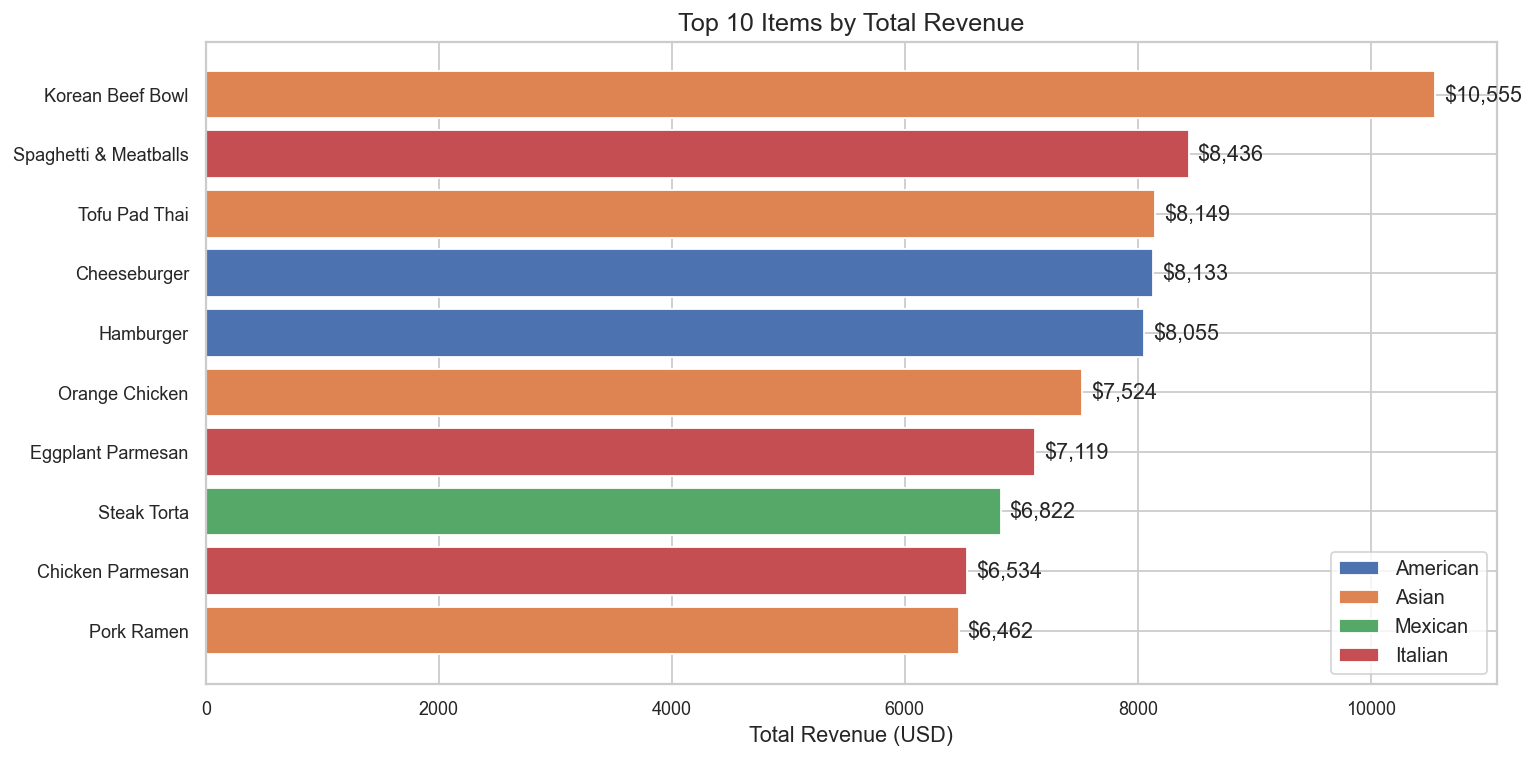

In [17]:
# ── Top 10 revenue-generating items ─────────────────────────────────────────
item_rev = df.groupby(['item_name', 'category']).agg(
    revenue=('price', 'sum'),
    qty=('item_id', 'count')
).reset_index().sort_values('revenue', ascending=False)

top10_rev = item_rev.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_rev['item_name'][::-1], top10_rev['revenue'][::-1],
               color=[CATEGORY_COLORS[c] for c in top10_rev['category'][::-1]],
               edgecolor='white')
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in top10_rev['revenue'][::-1]], padding=5)
ax.set_title('Top 10 Items by Total Revenue')
ax.set_xlabel('Total Revenue (USD)')

# Legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=v, label=k) for k, v in CATEGORY_COLORS.items()]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

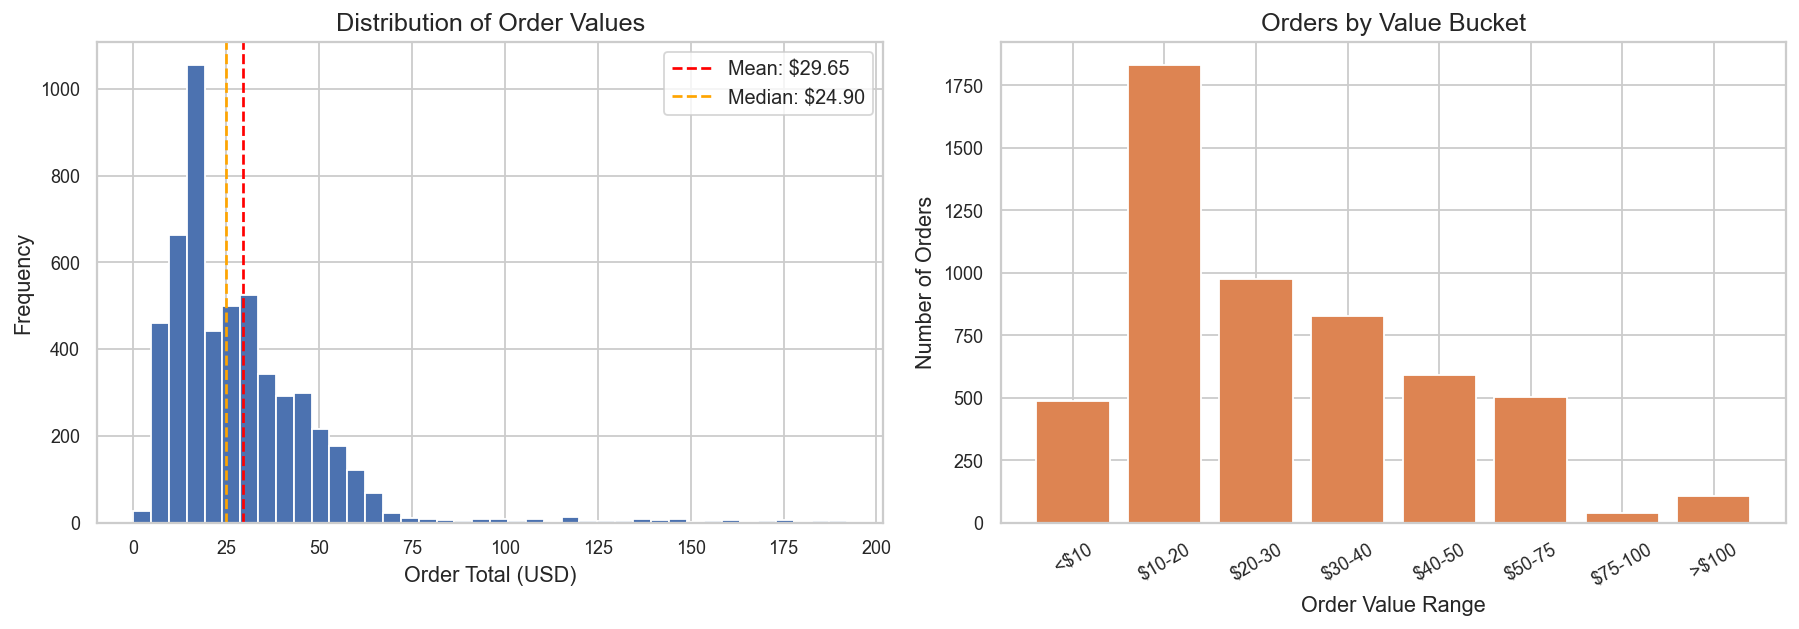


Order value percentiles:
count    5370.00
mean       29.65
std        22.70
min         0.00
25%        14.50
50%        24.90
75%        38.45
90%        52.85
95%        61.45
max       192.15
Name: price, dtype: float64


In [18]:
# ── Order value distribution ─────────────────────────────────────────────────
order_totals = df.groupby('order_id')['price'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(order_totals, bins=40, color='#4C72B0', edgecolor='white')
axes[0].axvline(order_totals.mean(), color='red', linestyle='--', label=f'Mean: ${order_totals.mean():.2f}')
axes[0].axvline(order_totals.median(), color='orange', linestyle='--', label=f'Median: ${order_totals.median():.2f}')
axes[0].set_title('Distribution of Order Values')
axes[0].set_xlabel('Order Total (USD)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Percentile buckets
bins = [0, 10, 20, 30, 40, 50, 75, 100, order_totals.max() + 1]
labels = ['<$10','$10-20','$20-30','$30-40','$40-50','$50-75','$75-100','>$100']
bucket = pd.cut(order_totals, bins=bins, labels=labels, right=False)
bucket_counts = bucket.value_counts().sort_index()
axes[1].bar(bucket_counts.index, bucket_counts.values, color='#DD8452', edgecolor='white')
axes[1].set_title('Orders by Value Bucket')
axes[1].set_xlabel('Order Value Range')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f'\nOrder value percentiles:')
print(order_totals.describe(percentiles=[.25,.5,.75,.9,.95]).round(2))

## 6. Time-Based Analysis

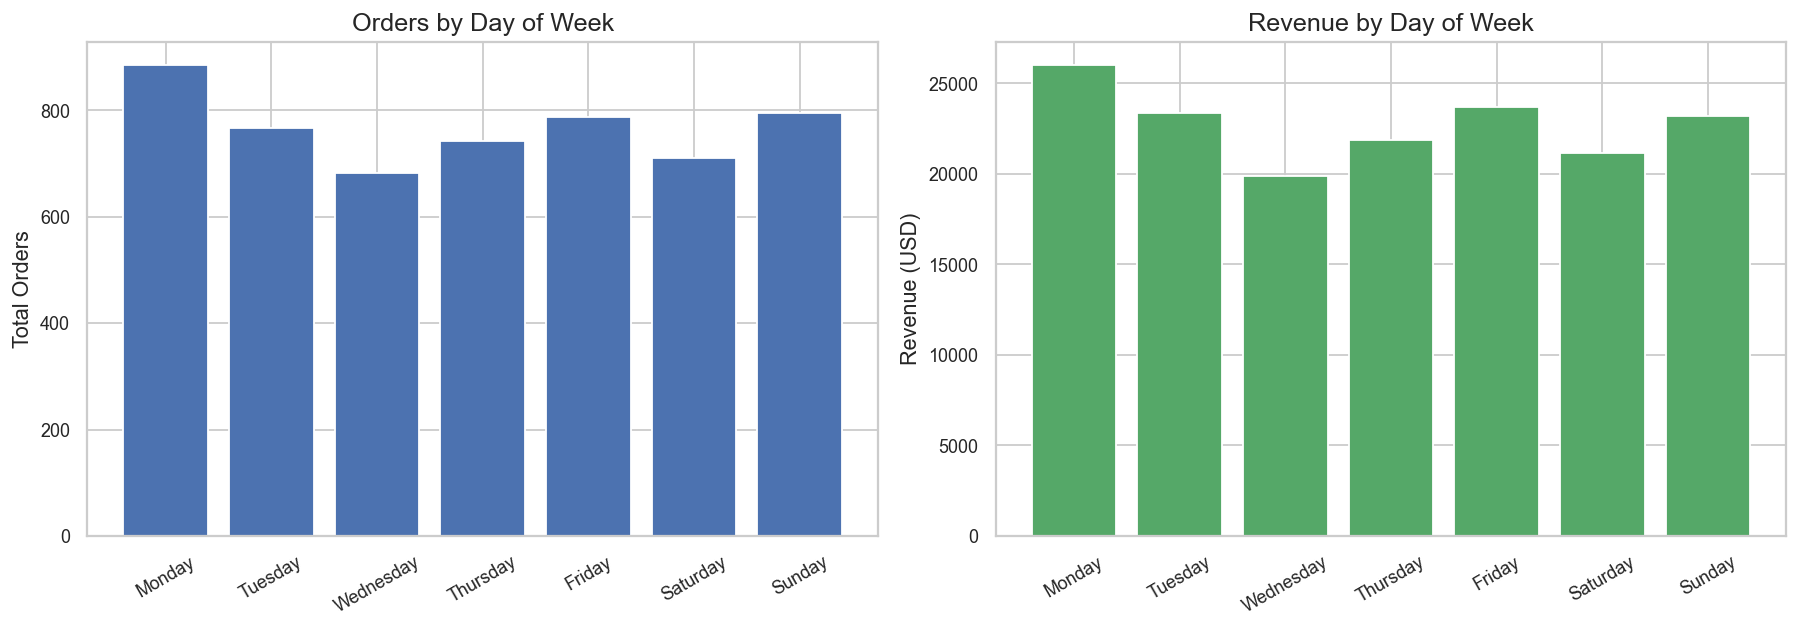

In [19]:
# ── Orders by day of week ────────────────────────────────────────────────────
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').agg(
    orders=('order_id', 'nunique'),
    revenue=('price', 'sum')
).reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow.index, dow['orders'], color='#4C72B0', edgecolor='white')
axes[0].set_title('Orders by Day of Week')
axes[0].set_ylabel('Total Orders')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow.index, dow['revenue'], color='#55A868', edgecolor='white')
axes[1].set_title('Revenue by Day of Week')
axes[1].set_ylabel('Revenue (USD)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

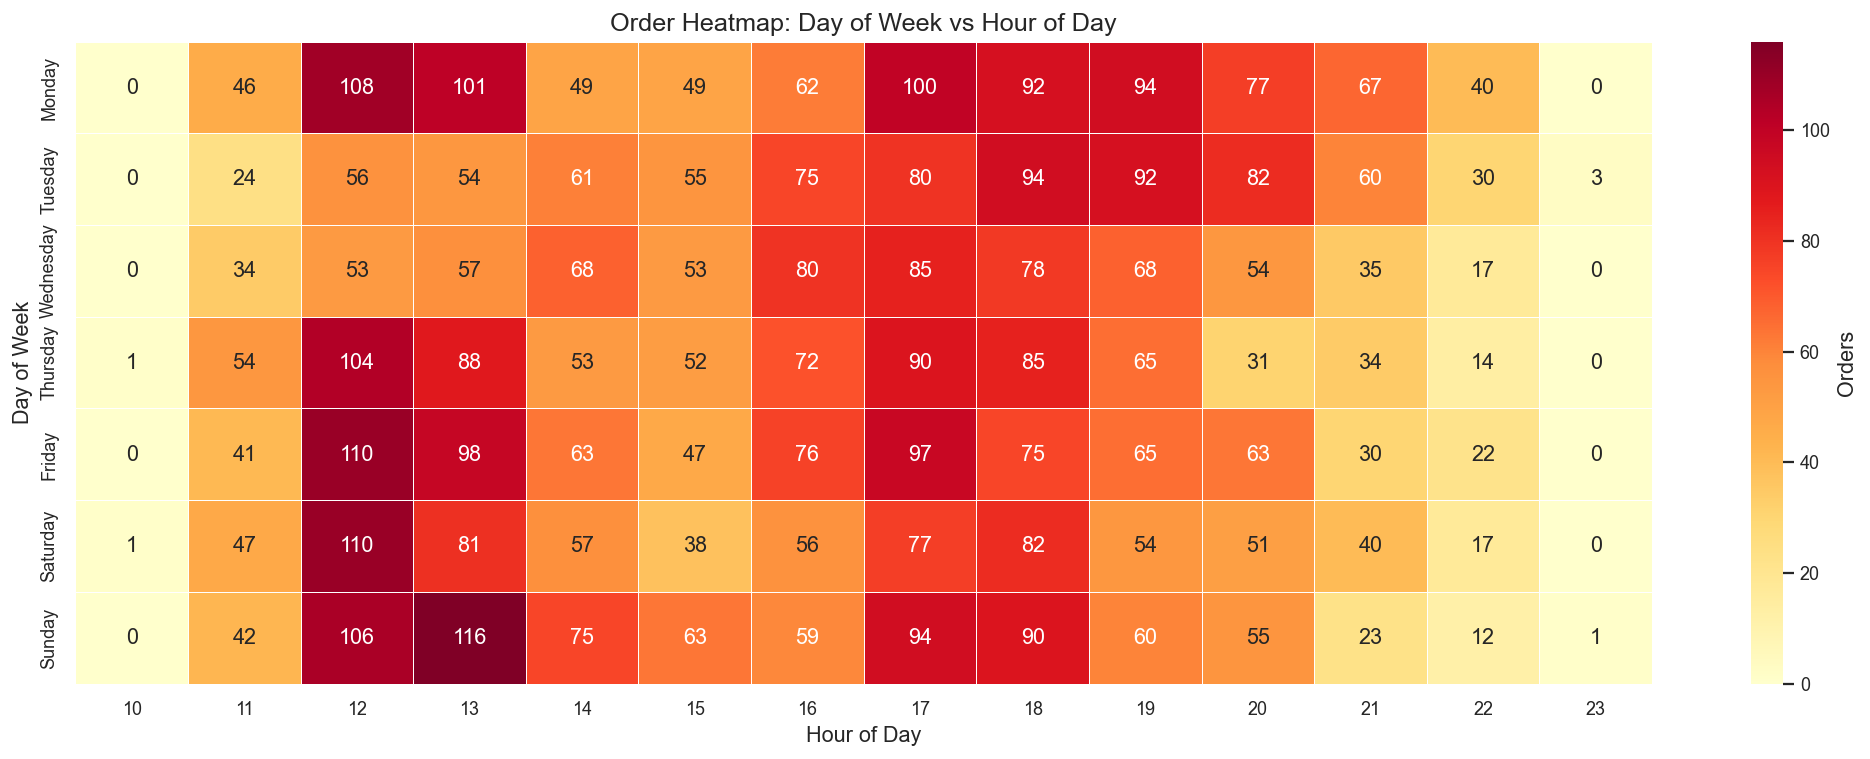

In [20]:
# ── Hourly order heatmap ─────────────────────────────────────────────────────
hourly = df.groupby(['day_of_week', 'hour'])['order_id'].nunique().reset_index()
hourly_pivot = hourly.pivot(index='day_of_week', columns='hour', values='order_id').reindex(dow_order).fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(hourly_pivot, cmap='YlOrRd', linewidths=0.4, linecolor='white',
            annot=True, fmt='.0f', ax=ax, cbar_kws={'label': 'Orders'})
ax.set_title('Order Heatmap: Day of Week vs Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

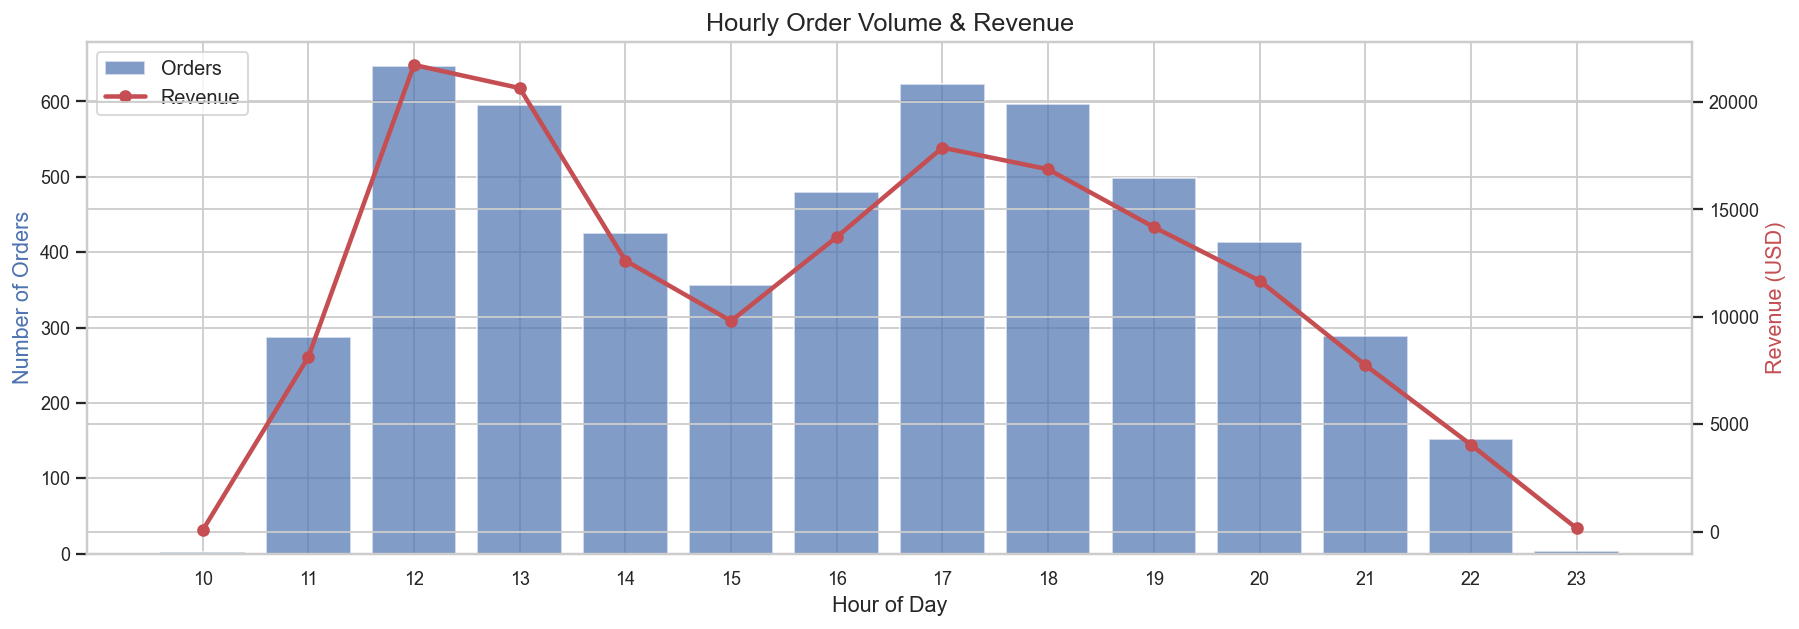

Peak order hour: 12:00 with 647 orders


In [21]:
# ── Peak hours analysis ──────────────────────────────────────────────────────
hourly_all = df.groupby('hour').agg(
    orders=('order_id', 'nunique'),
    revenue=('price', 'sum'),
    items=('item_id', 'count')
)

fig, ax = plt.subplots(figsize=(14, 5))
ax2 = ax.twinx()

ax.bar(hourly_all.index, hourly_all['orders'], color='#4C72B0', alpha=0.7, label='Orders')
ax2.plot(hourly_all.index, hourly_all['revenue'], color='#C44E52', linewidth=2.5,
         marker='o', label='Revenue')

ax.set_title('Hourly Order Volume & Revenue')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Orders', color='#4C72B0')
ax2.set_ylabel('Revenue (USD)', color='#C44E52')
ax.set_xticks(range(hourly_all.index.min(), hourly_all.index.max() + 1))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

peak_hour = hourly_all['orders'].idxmax()
print(f'Peak order hour: {peak_hour}:00 with {hourly_all.loc[peak_hour, "orders"]} orders')

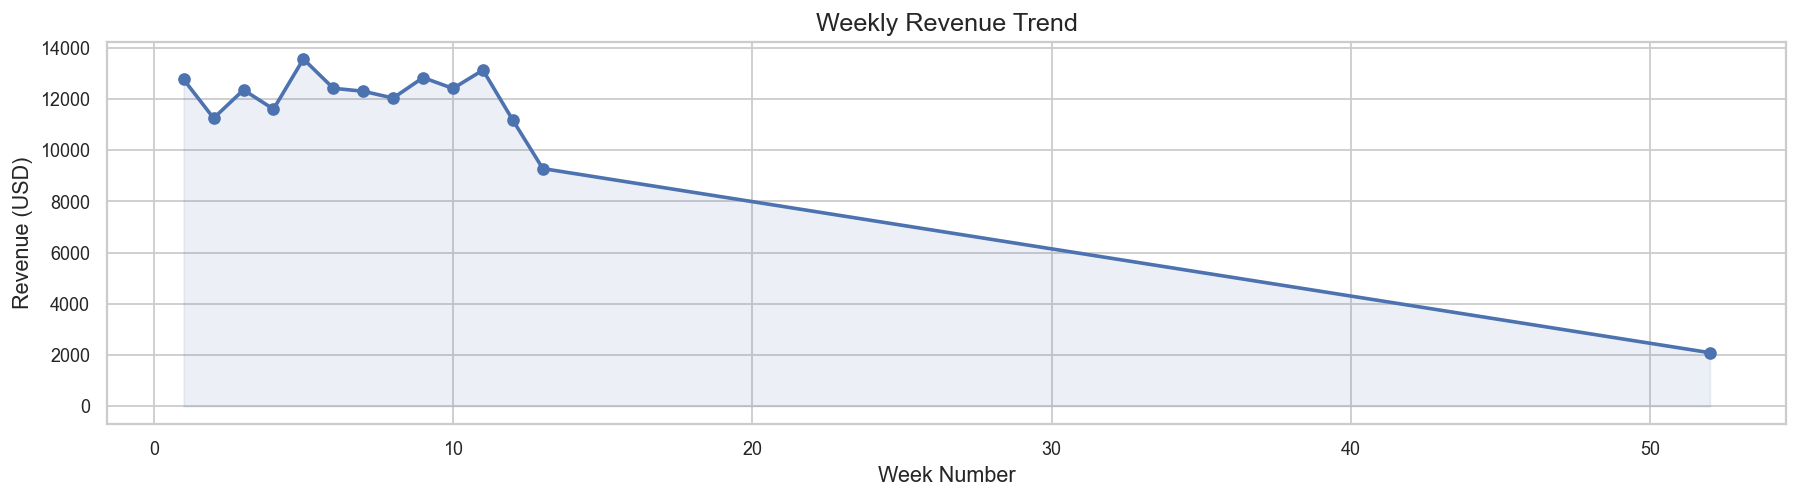

In [22]:
# ── Weekly trend ─────────────────────────────────────────────────────────────
weekly = df.groupby('week_number').agg(
    orders=('order_id', 'nunique'),
    revenue=('price', 'sum')
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly.index, weekly['revenue'], marker='o', color='#4C72B0', linewidth=2)
ax.fill_between(weekly.index, weekly['revenue'], alpha=0.1, color='#4C72B0')
ax.set_title('Weekly Revenue Trend')
ax.set_xlabel('Week Number')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()

## 7. Category Performance

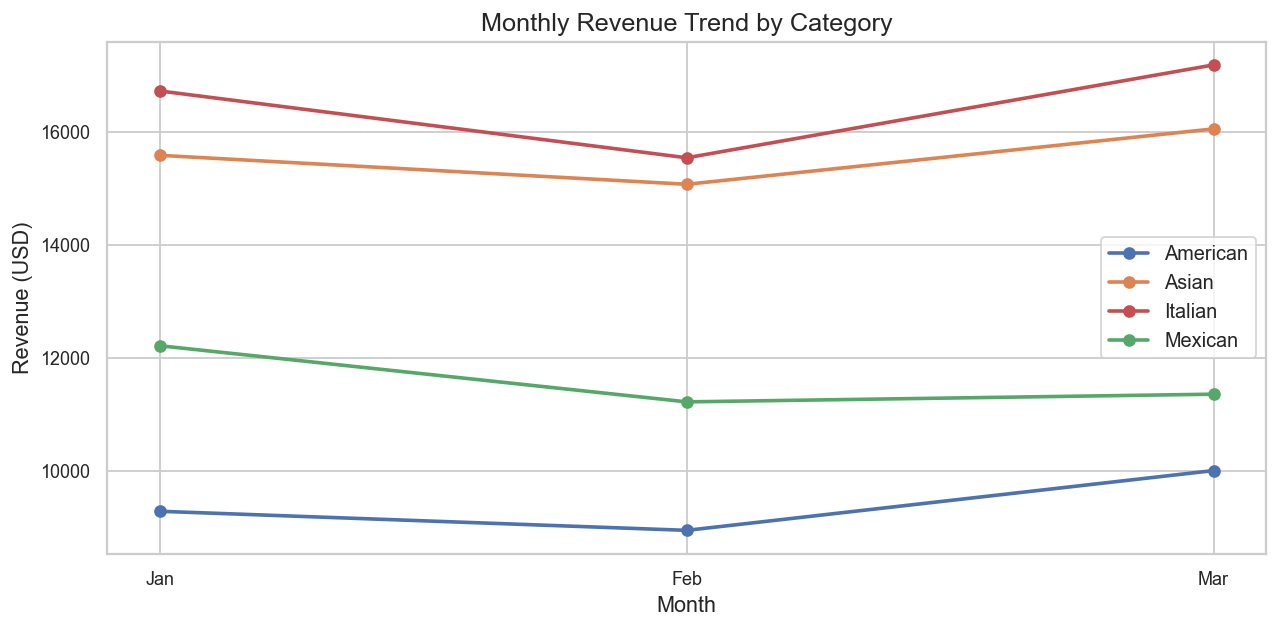

In [23]:
# ── Category monthly revenue trend ───────────────────────────────────────────
cat_monthly = df.groupby(['month', 'category'])['price'].sum().reset_index()
cat_monthly['month_name'] = cat_monthly['month'].map({1:'Jan', 2:'Feb', 3:'Mar'})

fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in cat_monthly.groupby('category'):
    ax.plot(grp['month_name'], grp['price'], marker='o',
            color=CATEGORY_COLORS[cat], label=cat, linewidth=2)
ax.set_title('Monthly Revenue Trend by Category')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (USD)')
ax.legend()
plt.tight_layout()
plt.show()

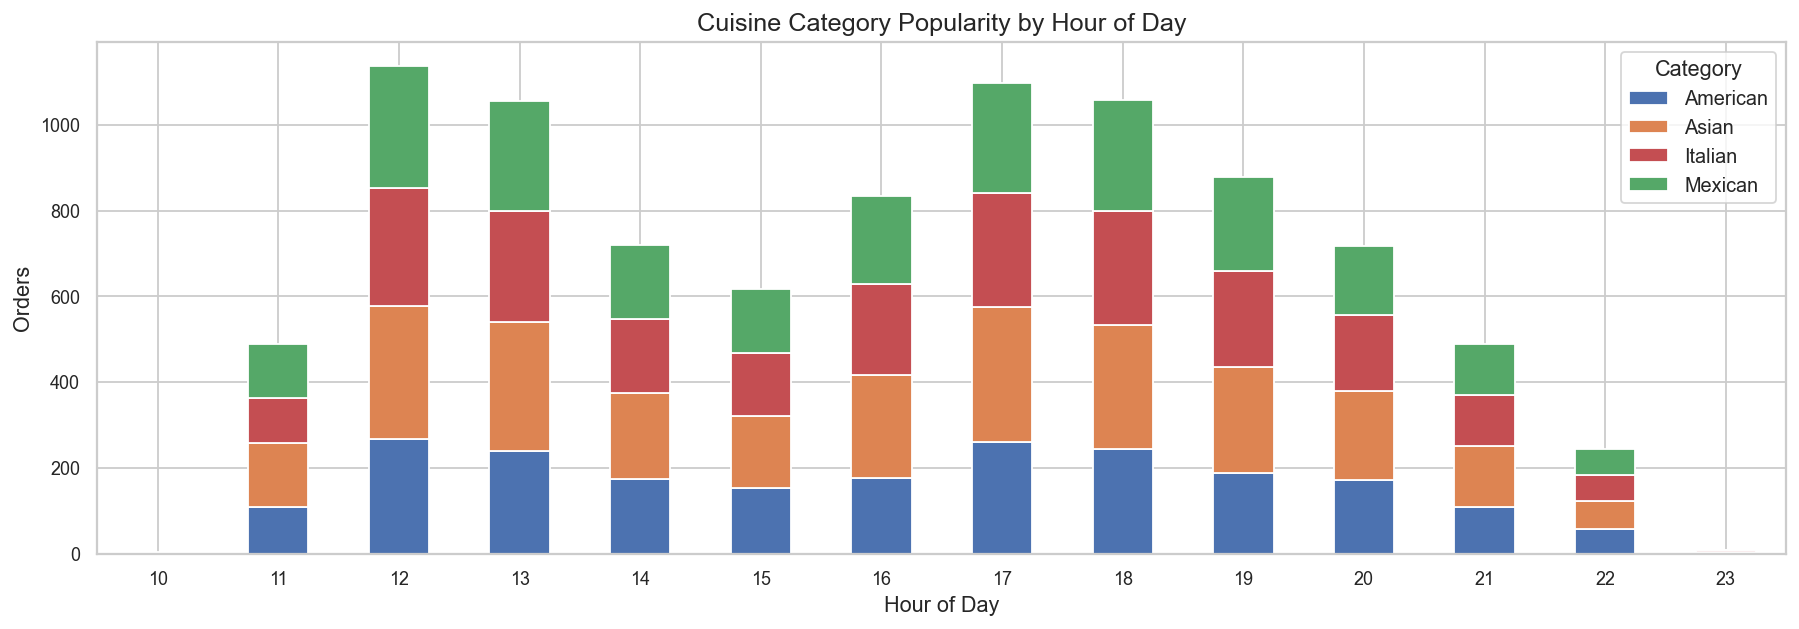

In [24]:
# ── Category popularity by time of day ──────────────────────────────────────
cat_hour = df.groupby(['hour', 'category'])['order_id'].nunique().reset_index()
cat_hour_pivot = cat_hour.pivot(index='hour', columns='category', values='order_id').fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
cat_hour_pivot.plot(kind='bar', stacked=True,
                    color=[CATEGORY_COLORS[c] for c in cat_hour_pivot.columns],
                    edgecolor='white', ax=ax)
ax.set_title('Cuisine Category Popularity by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Orders')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Category')
plt.tight_layout()
plt.show()

## 8. Item-Level Deep Dive

In [25]:
# ── Item popularity (order count) ────────────────────────────────────────────
item_pop = df.groupby(['item_name', 'category', 'price']).agg(
    qty_ordered=('item_id', 'count')
).reset_index().sort_values('qty_ordered', ascending=False)

print('TOP 10 most ordered items:')
print(item_pop.head(10).to_string(index=False))
print('\nBOTTOM 10 least ordered items:')
print(item_pop.tail(10).to_string(index=False))

TOP 10 most ordered items:
            item_name category  price  qty_ordered
            Hamburger American  12.95          622
              Edamame    Asian   5.00          620
     Korean Beef Bowl    Asian  17.95          588
         Cheeseburger American  13.95          583
         French Fries American   7.00          571
        Tofu Pad Thai    Asian  14.50          562
          Steak Torta  Mexican  13.95          489
Spaghetti & Meatballs  Italian  17.95          470
         Mac & Cheese American   7.00          463
        Chips & Salsa  Mexican   7.00          461

BOTTOM 10 least ordered items:
         item_name category  price  qty_ordered
           Hot Dog American   9.00          257
Fettuccine Alfredo  Italian  14.50          249
     Shrimp Scampi  Italian  19.95          239
     Veggie Burger American  10.50          238
 Chips & Guacamole  Mexican   9.00          237
Cheese Quesadillas  Mexican  10.50          233
       Steak Tacos  Mexican  13.95          

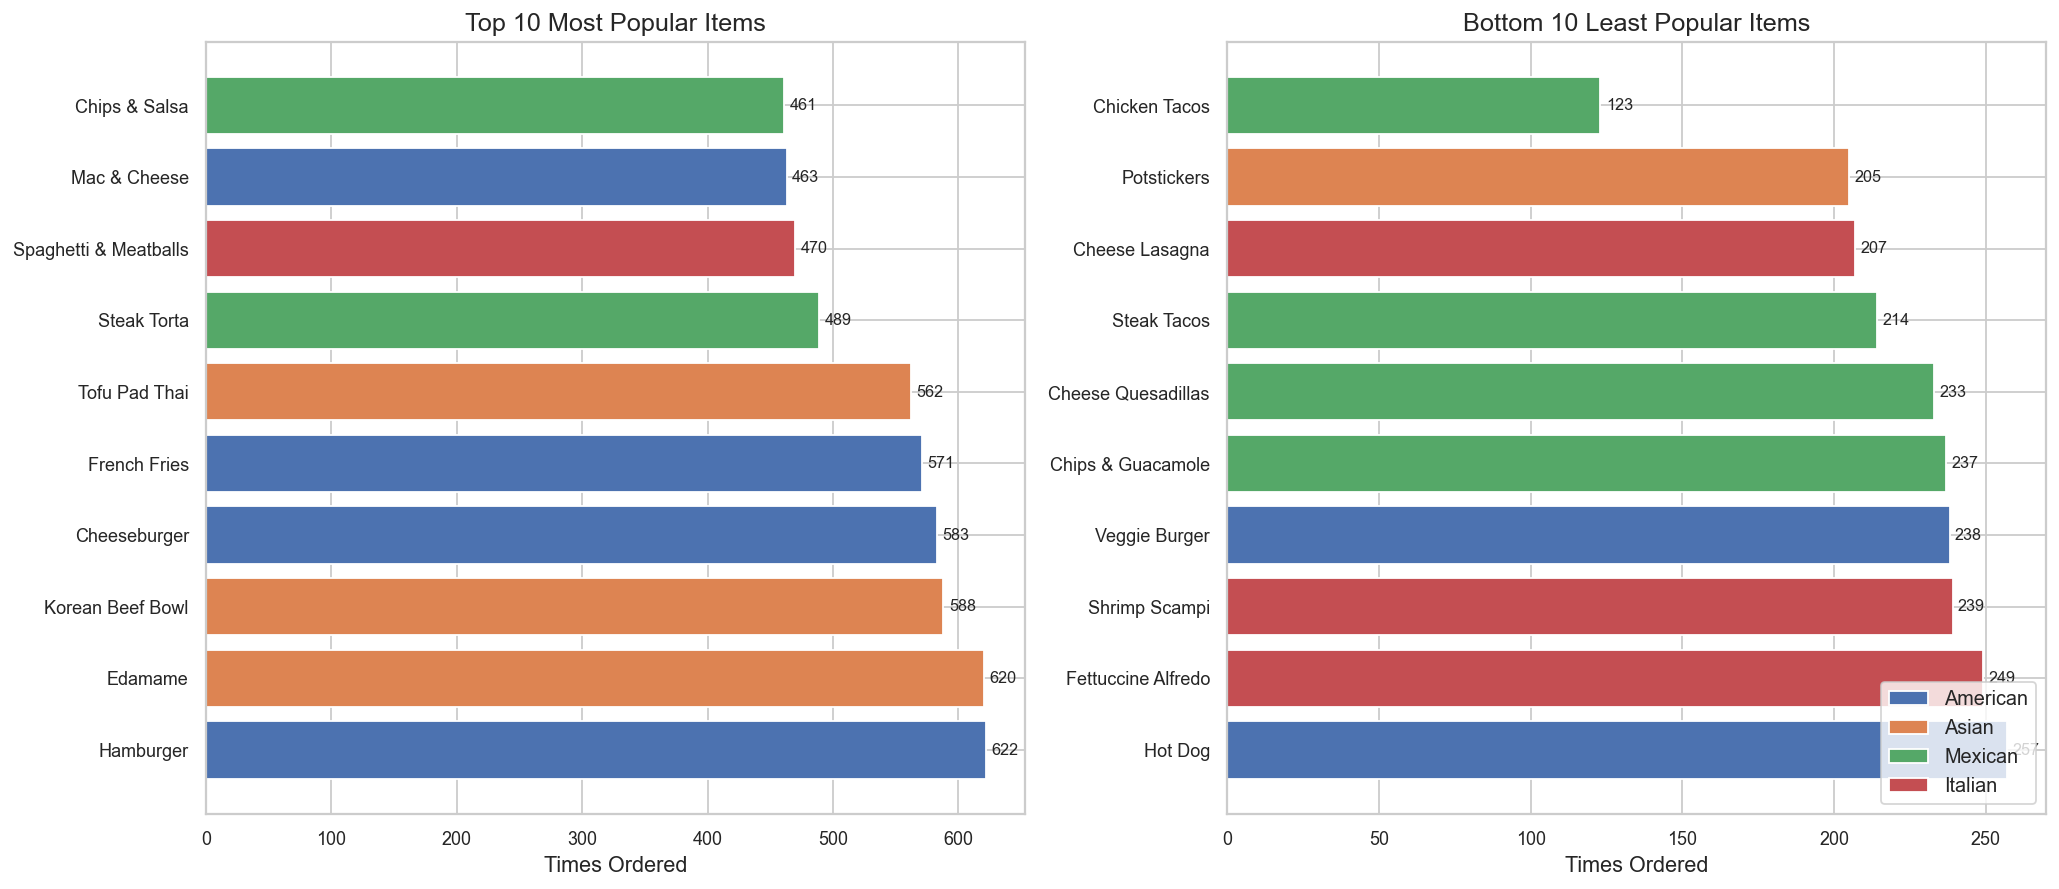

In [26]:
# ── Top & bottom 10 by orders (chart) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top10 = item_pop.head(10)
bot10 = item_pop.tail(10)

for ax, data, title, color in zip(
    axes,
    [top10, bot10],
    ['Top 10 Most Popular Items', 'Bottom 10 Least Popular Items'],
    ['#4C72B0', '#C44E52']
):
    b = ax.barh(data['item_name'], data['qty_ordered'],
                color=[CATEGORY_COLORS[c] for c in data['category']], edgecolor='white')
    ax.bar_label(b, padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Times Ordered')

handles = [Patch(facecolor=v, label=k) for k, v in CATEGORY_COLORS.items()]
axes[1].legend(handles=handles, loc='lower right')

plt.tight_layout()
plt.show()

In [27]:
# ── Full item scorecard ──────────────────────────────────────────────────────
item_scorecard = item_pop.merge(
    df.groupby('item_name')['price'].sum().reset_index().rename(columns={'price': 'total_revenue'}),
    on='item_name'
)
item_scorecard['revenue_share_%'] = (item_scorecard['total_revenue'] / item_scorecard['total_revenue'].sum() * 100).round(2)
item_scorecard['qty_share_%']     = (item_scorecard['qty_ordered']   / item_scorecard['qty_ordered'].sum()   * 100).round(2)
item_scorecard = item_scorecard.sort_values('qty_ordered', ascending=False)
print(item_scorecard[['item_name','category','price','qty_ordered','qty_share_%','total_revenue','revenue_share_%']].to_string(index=False))

            item_name category  price  qty_ordered  qty_share_%  total_revenue  revenue_share_%
            Hamburger American  12.95          622         5.14        8054.90             5.06
              Edamame    Asian   5.00          620         5.13        3100.00             1.95
     Korean Beef Bowl    Asian  17.95          588         4.86       10554.60             6.63
         Cheeseburger American  13.95          583         4.82        8132.85             5.11
         French Fries American   7.00          571         4.72        3997.00             2.51
        Tofu Pad Thai    Asian  14.50          562         4.65        8149.00             5.12
          Steak Torta  Mexican  13.95          489         4.04        6821.55             4.28
Spaghetti & Meatballs  Italian  17.95          470         3.89        8436.50             5.30
         Mac & Cheese American   7.00          463         3.83        3241.00             2.04
        Chips & Salsa  Mexican   7.00   

## 9. Order Complexity Analysis

Items per order stats:
count    5370.00
mean        2.25
std         1.67
min         0.00
25%         1.00
50%         2.00
75%         3.00
max        14.00
Name: item_id, dtype: float64

Max items in a single order: 14
Orders with 1 item: 2053
Orders with 5+ items: 182


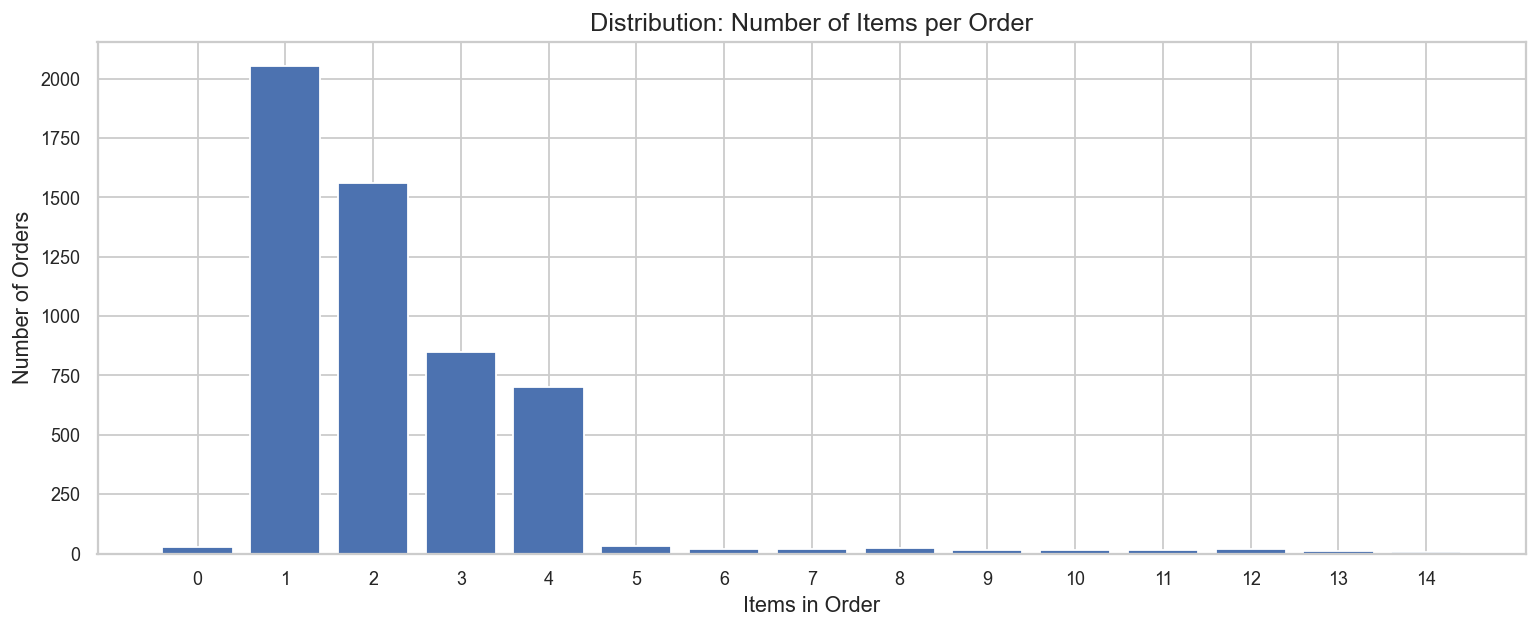

In [28]:
# ── Items per order distribution ─────────────────────────────────────────────
items_per_order = df.groupby('order_id')['item_id'].count()

print('Items per order stats:')
print(items_per_order.describe().round(2))
print(f'\nMax items in a single order: {items_per_order.max()}')
print(f'Orders with 1 item: {(items_per_order == 1).sum()}')
print(f'Orders with 5+ items: {(items_per_order >= 5).sum()}')

fig, ax = plt.subplots(figsize=(12, 5))
vc = items_per_order.value_counts().sort_index()
ax.bar(vc.index, vc.values, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution: Number of Items per Order')
ax.set_xlabel('Items in Order')
ax.set_ylabel('Number of Orders')
ax.set_xticks(vc.index)
plt.tight_layout()
plt.show()

In [31]:
# ── Largest orders ───────────────────────────────────────────────────────────
large_orders = df.groupby('order_id').agg(
    items=('item_id', 'count'),
    total=('price', 'sum'),
    categories=('category', lambda x: ', '.join(sorted(x.dropna().unique())))
).sort_values('total', ascending=False)

print('Top 10 largest orders by value:')
print(large_orders.head(10).to_string())

Top 10 largest orders by value:
          items   total                         categories
order_id                                                  
440          14  192.15  American, Asian, Italian, Mexican
2075         13  191.05  American, Asian, Italian, Mexican
1957         14  190.10  American, Asian, Italian, Mexican
330          14  189.70  American, Asian, Italian, Mexican
2675         14  185.10  American, Asian, Italian, Mexican
4482         13  184.50  American, Asian, Italian, Mexican
1274         13  183.55  American, Asian, Italian, Mexican
2188         13  182.65            Asian, Italian, Mexican
3473         14  182.55  American, Asian, Italian, Mexican
3583         13  179.60  American, Asian, Italian, Mexican


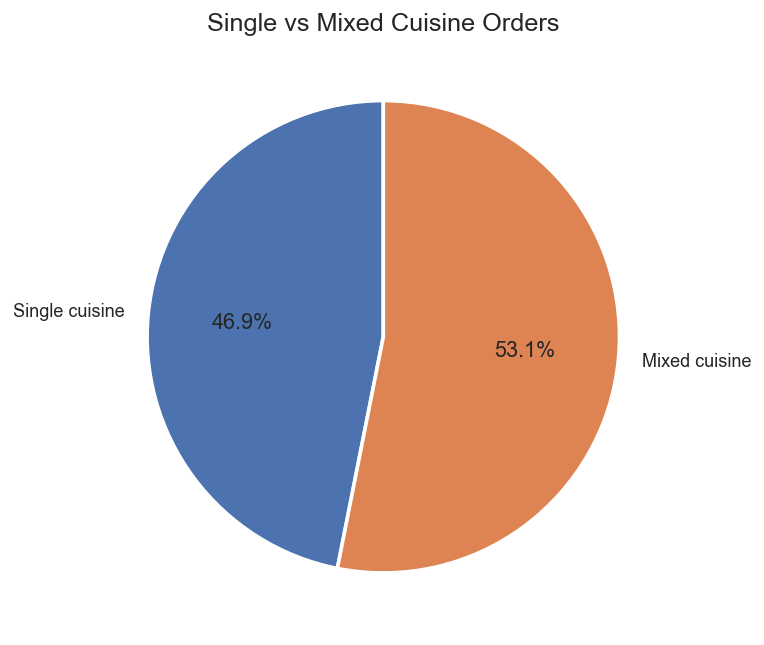

Single-cuisine orders : 2,505 (46.9%)
Mixed-cuisine orders  : 2,838 (53.1%)


In [32]:
# ── Mixed-category orders ────────────────────────────────────────────────────
order_cats = df.groupby('order_id')['category'].nunique()
mixed = (order_cats > 1).sum()
single = (order_cats == 1).sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([single, mixed], labels=['Single cuisine', 'Mixed cuisine'],
       autopct='%1.1f%%', colors=['#4C72B0','#DD8452'],
       wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
ax.set_title('Single vs Mixed Cuisine Orders')
plt.tight_layout()
plt.show()

print(f'Single-cuisine orders : {single:,} ({single/(single+mixed)*100:.1f}%)')
print(f'Mixed-cuisine orders  : {mixed:,} ({mixed/(single+mixed)*100:.1f}%)')

## 10. Popularity vs. Revenue Matrix (BCG-style)

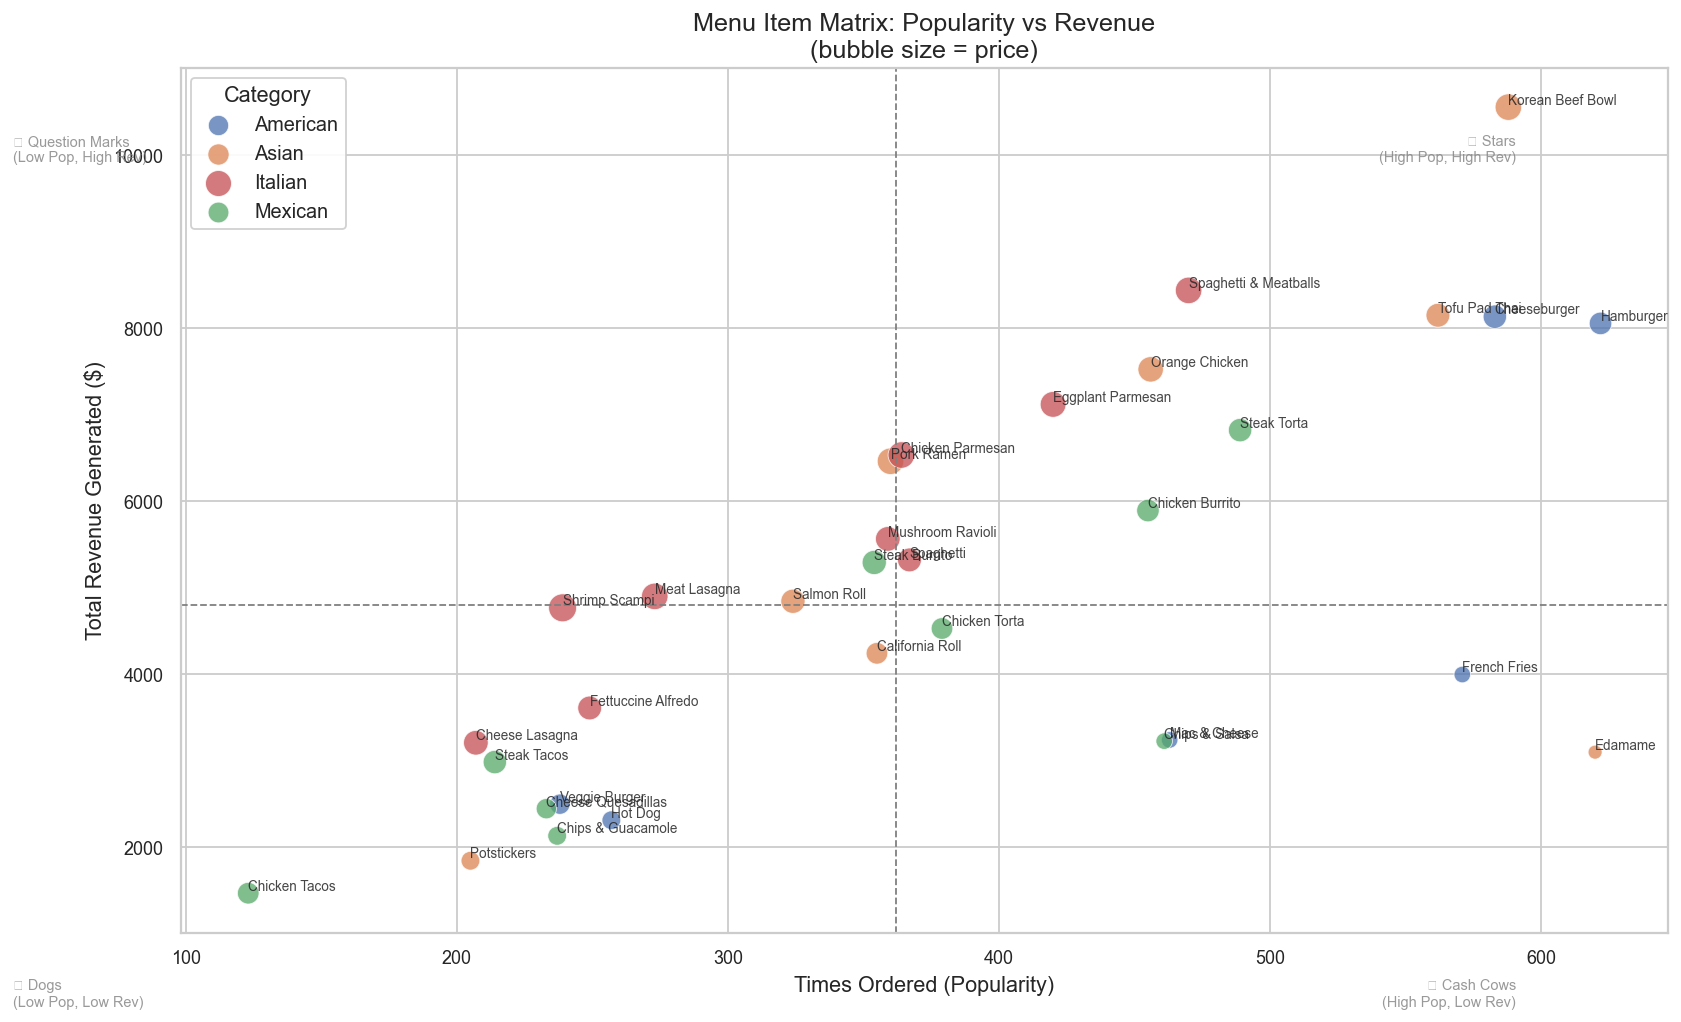

In [33]:
# ── Scatter: orders vs revenue per item ──────────────────────────────────────
scatter_df = item_scorecard.copy()

med_qty = scatter_df['qty_ordered'].median()
med_rev = scatter_df['total_revenue'].median()

fig, ax = plt.subplots(figsize=(13, 8))

for cat, grp in scatter_df.groupby('category'):
    ax.scatter(grp['qty_ordered'], grp['total_revenue'],
               color=CATEGORY_COLORS[cat], label=cat,
               s=grp['price'] * 12, alpha=0.75, edgecolors='white', linewidths=0.5)

for _, row in scatter_df.iterrows():
    ax.annotate(row['item_name'], (row['qty_ordered'], row['total_revenue']),
                fontsize=7.5, ha='left', va='bottom', alpha=0.85)

ax.axvline(med_qty, color='grey', linestyle='--', linewidth=1)
ax.axhline(med_rev, color='grey', linestyle='--', linewidth=1)

# Quadrant labels
for text, x, y, ha in [
    ('⭐ Stars\n(High Pop, High Rev)', scatter_df['qty_ordered'].max() * 0.95, scatter_df['total_revenue'].max() * 0.97, 'right'),
    ('🐕 Question Marks\n(Low Pop, High Rev)', med_qty * 0.1, scatter_df['total_revenue'].max() * 0.97, 'left'),
    ('🐄 Cash Cows\n(High Pop, Low Rev)', scatter_df['qty_ordered'].max() * 0.95, med_rev * 0.1, 'right'),
    ('🐟 Dogs\n(Low Pop, Low Rev)', med_qty * 0.1, med_rev * 0.1, 'left'),
]:
    ax.text(x, y, text, fontsize=8, color='grey', alpha=0.8, ha=ha, va='top')

ax.set_title('Menu Item Matrix: Popularity vs Revenue\n(bubble size = price)', fontsize=14)
ax.set_xlabel('Times Ordered (Popularity)')
ax.set_ylabel('Total Revenue Generated ($)')
ax.legend(title='Category', framealpha=0.9)
plt.tight_layout()
plt.show()

## 11. Combo / Co-occurrence Analysis

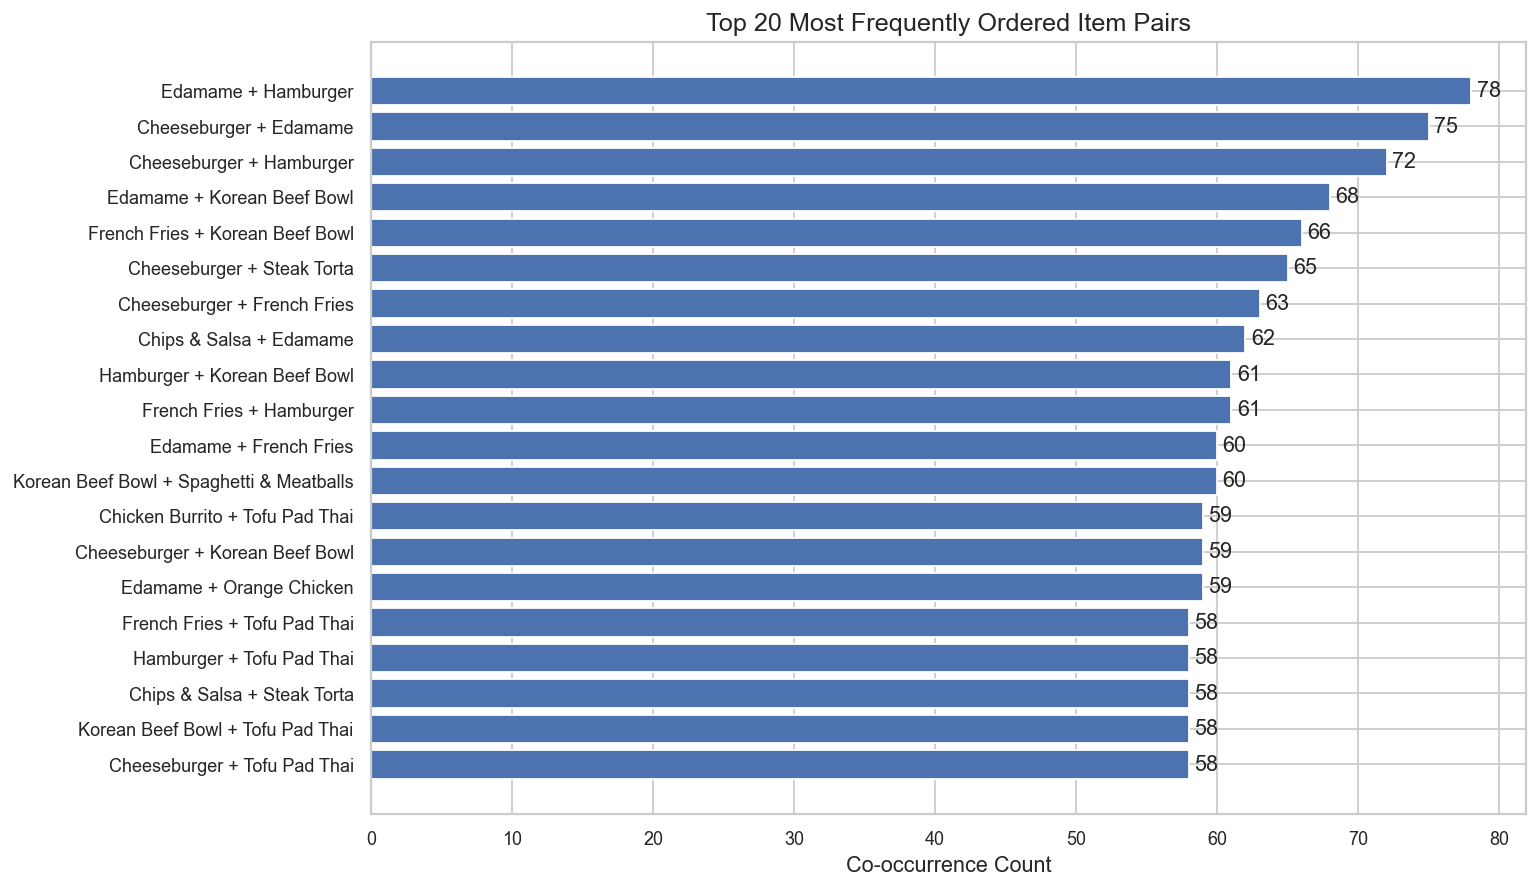


Top 10 most ordered together:
       item_a           item_b  count
      Edamame        Hamburger     78
 Cheeseburger          Edamame     75
 Cheeseburger        Hamburger     72
      Edamame Korean Beef Bowl     68
 French Fries Korean Beef Bowl     66
 Cheeseburger      Steak Torta     65
 Cheeseburger     French Fries     63
Chips & Salsa          Edamame     62
    Hamburger Korean Beef Bowl     61
 French Fries        Hamburger     61


In [35]:
# ── Which items are ordered together most often? ─────────────────────────────
order_items = df.groupby('order_id')['item_name'].apply(
    lambda x: [i for i in x if pd.notna(i)]
)
# Only multi-item orders
multi_orders = order_items[order_items.apply(len) > 1]

pair_counts = Counter()
for items in multi_orders:
    for pair in combinations(sorted(set(items)), 2):
        pair_counts[pair] += 1

top_pairs = pd.DataFrame(pair_counts.most_common(20),
                         columns=['pair', 'count'])
top_pairs['item_a'] = top_pairs['pair'].apply(lambda x: x[0])
top_pairs['item_b'] = top_pairs['pair'].apply(lambda x: x[1])

fig, ax = plt.subplots(figsize=(12, 7))
b = ax.barh(top_pairs.apply(lambda r: f"{r['item_a']} + {r['item_b']}", axis=1)[::-1],
            top_pairs['count'][::-1], color='#4C72B0', edgecolor='white')
ax.bar_label(b, padding=3)
ax.set_title('Top 20 Most Frequently Ordered Item Pairs')
ax.set_xlabel('Co-occurrence Count')
plt.tight_layout()
plt.show()

print('\nTop 10 most ordered together:')
print(top_pairs[['item_a','item_b','count']].head(10).to_string(index=False))

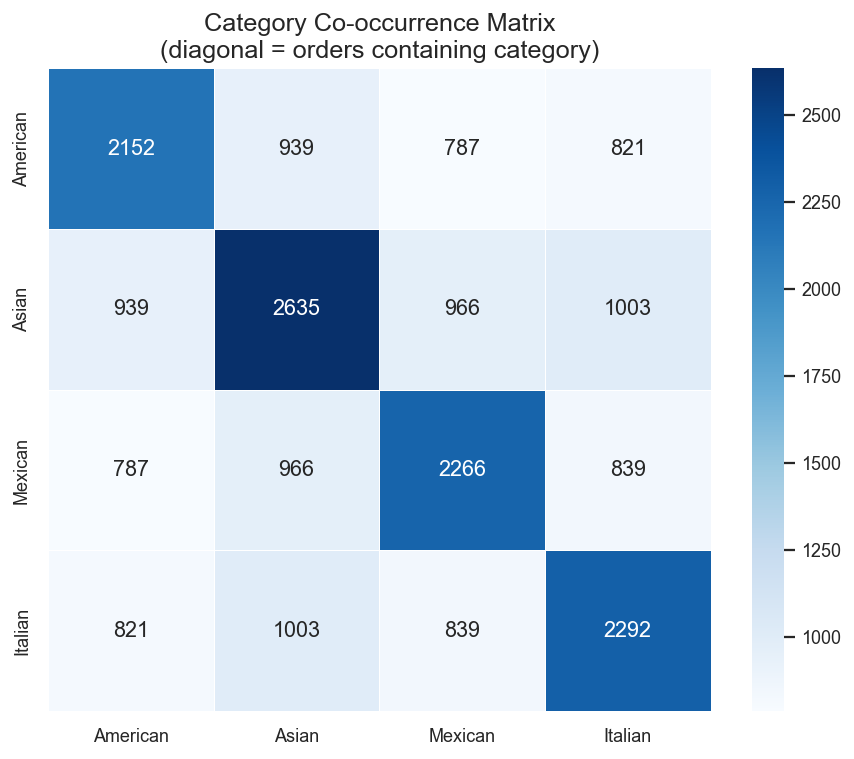

In [37]:
# ── Category-level co-occurrence heatmap ──────────────────────────────────────
order_cats_list = df.groupby('order_id')['category'].apply(
    lambda x: [i for i in x if pd.notna(i)]
)
multi_cat_orders = order_cats_list[order_cats_list.apply(len) > 1]

cat_pair_counts = Counter()
cats = list(CATEGORY_COLORS.keys())
for cat_list in multi_cat_orders:
    for pair in combinations(sorted(set(cat_list)), 2):
        cat_pair_counts[pair] += 1

co_matrix = pd.DataFrame(0, index=cats, columns=cats)
for (a, b), cnt in cat_pair_counts.items():
    co_matrix.loc[a, b] = cnt
    co_matrix.loc[b, a] = cnt
for c in cats:
    co_matrix.loc[c, c] = (df[df['category'] == c]['order_id'].nunique())

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Category Co-occurrence Matrix\n(diagonal = orders containing category)')
plt.tight_layout()
plt.show()

## 12. Business Insights Summary

In [38]:
# ── Final findings ───────────────────────────────────────────────────────────

# Best and worst days
best_day_orders  = dow['orders'].idxmax()
worst_day_orders = dow['orders'].idxmin()
best_month       = monthly['revenue'].idxmax()
worst_month      = monthly['revenue'].idxmin()
peak_hr          = hourly_all['orders'].idxmax()
slow_hr          = hourly_all['orders'].idxmin()
top_item         = item_pop.iloc[0]
bot_item         = item_pop.iloc[-1]
top_cat          = cat_revenue.index[0]
bot_cat          = cat_revenue.index[-1]
avg_ov           = order_totals.mean()
med_ov           = order_totals.median()

print('=' * 65)
print('           🍽️  RESTAURANT BUSINESS INSIGHTS SUMMARY')
print('=' * 65)

print(f"""
📊 OVERALL KPIs
  • Total Orders          : {total_orders:,}
  • Total Items Sold      : {total_items:,}
  • Total Revenue         : ${total_revenue:,.2f}
  • Avg Order Value       : ${avg_ov:.2f}  (Median: ${med_ov:.2f})
  • Avg Items / Order     : {avg_items_per:.2f}
  • Avg Daily Revenue     : ${total_revenue/days:,.2f}
  • Avg Daily Orders      : {total_orders/days:.1f}

📅 TIME PATTERNS
  • Best Day (orders)     : {best_day_orders}
  • Slowest Day (orders)  : {worst_day_orders}
  • Best Month (revenue)  : {best_month}
  • Slowest Month         : {worst_month}
  • Peak Hour             : {peak_hr}:00
  • Slowest Hour          : {slow_hr}:00

🍜 CATEGORY PERFORMANCE
  • Top Revenue Category  : {top_cat} (${cat_revenue.loc[top_cat,'total_revenue']:,.2f} | {cat_revenue.loc[top_cat,'revenue_share_%']}%)
  • Low Revenue Category  : {bot_cat} (${cat_revenue.loc[bot_cat,'total_revenue']:,.2f} | {cat_revenue.loc[bot_cat,'revenue_share_%']}%)
  • Priciest Category     : {menu.groupby('category')['price'].mean().idxmax()}

🌟 TOP & BOTTOM ITEMS
  • Most Ordered Item     : {top_item['item_name']} ({int(top_item['qty_ordered'])} orders, ${top_item['price']:.2f})
  • Least Ordered Item    : {bot_item['item_name']} ({int(bot_item['qty_ordered'])} orders, ${bot_item['price']:.2f})
  • Highest Revenue Item  : {item_rev.iloc[0]['item_name']} (${item_rev.iloc[0]['revenue']:,.2f})
  • Most Expensive Item   : {menu.loc[menu['price'].idxmax(),'item_name']} (${menu['price'].max():.2f})
  • Cheapest Item         : {menu.loc[menu['price'].idxmin(),'item_name']} (${menu['price'].min():.2f})

🔗 ORDER COMPLEXITY
  • Single-item orders    : {(items_per_order == 1).sum():,} ({(items_per_order==1).mean()*100:.1f}%)
  • 5+ item orders        : {(items_per_order >= 5).sum():,}
  • Largest single order  : {items_per_order.max()} items
  • Single-cuisine orders : {single:,} ({single/(single+mixed)*100:.1f}%)
  • Mixed-cuisine orders  : {mixed:,} ({mixed/(single+mixed)*100:.1f}%)

🤝 TOP ITEM COMBOS
  • #{top_pairs.iloc[0]['item_a']} + {top_pairs.iloc[0]['item_b']} ({top_pairs.iloc[0]['count']} times)
  • #{top_pairs.iloc[1]['item_a']} + {top_pairs.iloc[1]['item_b']} ({top_pairs.iloc[1]['count']} times)
  • #{top_pairs.iloc[2]['item_a']} + {top_pairs.iloc[2]['item_b']} ({top_pairs.iloc[2]['count']} times)
""")

print('=' * 65)
print('💡 KEY RECOMMENDATIONS')
print('=' * 65)
print(f"""
1. MENU ENGINEERING: Items in the 'Dogs' quadrant (low popularity,
   low revenue) should be re-evaluated for removal or re-pricing.

2. PEAK HOUR STAFFING: Hour {peak_hr}:00 is the busiest — ensure
   sufficient staff and prep during this window.

3. UPSELLING: Leverage top item combos (e.g.,
   {top_pairs.iloc[0]['item_a']} + {top_pairs.iloc[0]['item_b']})
   for combo meal promotions.

4. CATEGORY FOCUS: {top_cat} dominates revenue — consider expanding
   this cuisine line. {bot_cat} underperforms and may need promotion.

5. SLOW DAY PROMOTIONS: {worst_day_orders} is the slowest day —
   targeted discounts or events could lift sales.

6. HIGH-VALUE ORDERS: {(items_per_order >= 5).sum()} large orders (5+ items)
   represent significant revenue — loyalty programs for frequent
   large-order customers could boost retention.
""")

           🍽️  RESTAURANT BUSINESS INSIGHTS SUMMARY

📊 OVERALL KPIs
  • Total Orders          : 5,370
  • Total Items Sold      : 12,234
  • Total Revenue         : $159,217.90
  • Avg Order Value       : $29.65  (Median: $24.90)
  • Avg Items / Order     : 2.25
  • Avg Daily Revenue     : $1,769.09
  • Avg Daily Orders      : 59.7

📅 TIME PATTERNS
  • Best Day (orders)     : Monday
  • Slowest Day (orders)  : Wednesday
  • Best Month (revenue)  : Mar
  • Slowest Month         : Feb
  • Peak Hour             : 12:00
  • Slowest Hour          : 10:00

🍜 CATEGORY PERFORMANCE
  • Top Revenue Category  : Italian ($49,462.70 | 31.1%)
  • Low Revenue Category  : American ($28,237.75 | 17.7%)
  • Priciest Category     : Italian

🌟 TOP & BOTTOM ITEMS
  • Most Ordered Item     : Hamburger (622 orders, $12.95)
  • Least Ordered Item    : Chicken Tacos (123 orders, $11.95)
  • Highest Revenue Item  : Korean Beef Bowl ($10,554.60)
  • Most Expensive Item   : Shrimp Scampi ($19.95)
  • Cheapest Ite